In [55]:
import matplotlib.pyplot as plt
import pandas as pd
import math, numpy as np

In [56]:
file = '../data/outs/all_time.csv'

try:
    df = pd.read_csv(file, sep=' ')
    print("Dados lidos com sucesso!")

except FileNotFoundError:
    print(f"Erro: Arquivo '{file}' não encontrado!")

Dados lidos com sucesso!


In [57]:
df.dtypes

nome      object
n          int64
m          int64
c          int64
fila      object
run        int64
l1         int64
l2         int64
llc        int64
cycles     int64
inst       int64
dtype: object

In [58]:
df.head()

,nome,n,m,c,fila,run,l1,l2,llc,cycles,inst
0,NY,264346,733846,36946,BINH,212,2282354,1113077,113176,949773676,2653683718
1,NY,264346,733846,36946,BINH,213,2257437,1104738,111952,958366252,2653679198
2,NY,264346,733846,36946,BINH,212,2283957,1121149,112447,947152037,2653690696
3,NY,264346,733846,36946,BINH,214,2293844,1121992,111556,959102432,2653691042
4,NY,264346,733846,36946,BINH,212,2320663,1150452,110389,948291267,2653691059


## Tempo de execução por quantidade de vértices

In [59]:
df_run_n = (
    df.groupby(['nome', 'fila'], as_index=False)
      .agg(run_mean=('run', 'mean'),
           run_std=('run', 'std'),
           run_var=('run', 'var'))
)

df_merged = df.merge(df_run_n, on=['nome', 'fila'], how='left')
df_merged.head()

,nome,n,m,c,fila,run,l1,l2,llc,cycles,inst,run_mean,run_std,run_var
0,NY,264346,733846,36946,BINH,212,2282354,1113077,113176,949773676,2653683718,212.7,0.823273,0.677778
1,NY,264346,733846,36946,BINH,213,2257437,1104738,111952,958366252,2653679198,212.7,0.823273,0.677778
2,NY,264346,733846,36946,BINH,212,2283957,1121149,112447,947152037,2653690696,212.7,0.823273,0.677778
3,NY,264346,733846,36946,BINH,214,2293844,1121992,111556,959102432,2653691042,212.7,0.823273,0.677778
4,NY,264346,733846,36946,BINH,212,2320663,1150452,110389,948291267,2653691059,212.7,0.823273,0.677778


In [60]:
df_run_n2 = df_merged[df_merged['fila'].isin(["BINH", "2LVBQDK"])]
df_run_n2

,nome,n,m,c,fila,run,l1,l2,llc,cycles,inst,run_mean,run_std,run_var
0,NY,264346,733846,36946,BINH,212,2282354,1113077,113176,949773676,2653683718,212.7,0.823273,0.677778
1,NY,264346,733846,36946,BINH,213,2257437,1104738,111952,958366252,2653679198,212.7,0.823273,0.677778
2,NY,264346,733846,36946,BINH,212,2283957,1121149,112447,947152037,2653690696,212.7,0.823273,0.677778
3,NY,264346,733846,36946,BINH,214,2293844,1121992,111556,959102432,2653691042,212.7,0.823273,0.677778
4,NY,264346,733846,36946,BINH,212,2320663,1150452,110389,948291267,2653691059,212.7,0.823273,0.677778
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1035,USA,23947347,58333344,368855,2LVBQDK,7970,511290894,503072878,27433871,33286059780,51678345971,7975.8,7.842902,61.511111
1036,USA,23947347,58333344,368855,2LVBQDK,7981,511278710,501590697,27355566,33315344344,51678345983,7975.8,7.842902,61.511111
1037,USA,23947347,58333344,368855,2LVBQDK,7987,511159066,501242684,27353558,33320113827,51678345971,7975.8,7.842902,61.511111
1038,USA,23947347,58333344,368855,2LVBQDK,7976,511132972,501300587,27391200,33304415922,51678345963,7975.8,7.842902,61.511111


In [61]:
df_pivot = df_run_n2.pivot_table(
    index=['nome', 'n', 'm', 'c'],          # linhas (ex: BAY, CAL, COL...)
    columns=['fila'],        # vira colunas (BINH, 2LVBQDK)
    values=['run_mean', 'run_std'] # valores que você quer
)

df_pivot

run_mean            run_std           
fila                           2LVBQDK     BINH   2LVBQDK       BINH
nome n        m        c                                            
BAY  321270   800172   94305      78.7    257.8  0.483046   1.475730
CAL  1890815  4657742  215354    505.1   1795.5  1.911951   3.951090
COL  435666   1057066  137384    110.5    381.0  0.527046   2.905933
CTR  14081816 34292496 214013   5521.9  12877.4  3.573047  16.180922
E    3598623  8778114  200760   1042.2   3093.9  1.873796  24.002083
FLA  1070376  2712798  214013    272.6   1011.1  0.699206   5.782156
LKS  2758119  6885658  138911    767.8   2448.6  4.894441   5.985167
NE   1524453  3897636  63247     443.6   1318.7  2.011080   3.128720
NW   1207945  2840208  128569    325.3   1087.1  1.946507  13.731149
NY   264346   733846   36946      65.0    212.7  0.816497   0.823273
USA  23947347 58333344 368855   7975.8  15239.0  7.842902  81.069243
W    6262104  15248146 368855   1882.3   3983.7  2.869379   6.815831

In [62]:

df_pivot = df_pivot.reset_index()
df_pivot['sqrt_c'] = df_pivot['c'].apply(math.sqrt)
df_pivot['log_n'] = df_pivot['n'].apply(math.log2)

# Razões — "quantas vezes maior"
df_pivot['sqrt_vs_log_ratio'] = df_pivot['sqrt_c'] / df_pivot['log_n']
df_pivot

nome         n         m       c run_mean            run_std             \
fila                                   2LVBQDK     BINH   2LVBQDK       BINH   
0     BAY    321270    800172   94305     78.7    257.8  0.483046   1.475730   
1     CAL   1890815   4657742  215354    505.1   1795.5  1.911951   3.951090   
2     COL    435666   1057066  137384    110.5    381.0  0.527046   2.905933   
3     CTR  14081816  34292496  214013   5521.9  12877.4  3.573047  16.180922   
4       E   3598623   8778114  200760   1042.2   3093.9  1.873796  24.002083   
5     FLA   1070376   2712798  214013    272.6   1011.1  0.699206   5.782156   
6     LKS   2758119   6885658  138911    767.8   2448.6  4.894441   5.985167   
7      NE   1524453   3897636   63247    443.6   1318.7  2.011080   3.128720   
8      NW   1207945   2840208  128569    325.3   1087.1  1.946507  13.731149   
9      NY    264346    733846   36946     65.0    212.7  0.816497   0.823273   
10    USA  23947347  58333344  368855   7975.8  15239.0  7.842902  81.069243   
11      W   6262104  15248146  368855   1882.3   3983.7  2.869379   6.815831   

          sqrt_c      log_n sqrt_vs_log_ratio  
fila                                           
0     307.091192  18.293427         16.786969  
1     464.062496  20.850577         22.256578  
2     370.653477  18.732863         19.786270  
3     462.615391  23.747330         19.480733  
4     448.062496  21.779014         20.573131  
5     462.615391  20.029686         23.096487  
6     372.707660  21.395253         17.420110  
7     251.489562  20.539860         12.243976  
8     358.565196  20.204123         17.747130  
9     192.213423  18.012068         10.671369  
10    607.334340  24.513363         24.775644  
11    607.334340  22.578216         26.899129

In [64]:
latex = df_pivot.to_latex(
    index=False,
    column_format="|lrrrrrrr|",
    caption="Características dos grafos e tempo de execução do Dijkstra...",
    label="tab:res",
    float_format="%.1f"
)

print(latex)

\begin{table}
\caption{Características dos grafos e tempo de execução do Dijkstra...}
\label{tab:res}
\begin{tabular}{|lrrrrrrr|}
\toprule
nome & n & m & c & \multicolumn{2}{r}{run_mean} & \multicolumn{2}{r}{run_std} & sqrt_c & log_n & sqrt_vs_log_ratio \\
 &  &  &  & 2LVBQDK & BINH & 2LVBQDK & BINH &  &  &  \\
\midrule
BAY & 321270 & 800172 & 94305 & 78.7 & 257.8 & 0.5 & 1.5 & 307.1 & 18.3 & 16.8 \\
CAL & 1890815 & 4657742 & 215354 & 505.1 & 1795.5 & 1.9 & 4.0 & 464.1 & 20.9 & 22.3 \\
COL & 435666 & 1057066 & 137384 & 110.5 & 381.0 & 0.5 & 2.9 & 370.7 & 18.7 & 19.8 \\
CTR & 14081816 & 34292496 & 214013 & 5521.9 & 12877.4 & 3.6 & 16.2 & 462.6 & 23.7 & 19.5 \\
E & 3598623 & 8778114 & 200760 & 1042.2 & 3093.9 & 1.9 & 24.0 & 448.1 & 21.8 & 20.6 \\
FLA & 1070376 & 2712798 & 214013 & 272.6 & 1011.1 & 0.7 & 5.8 & 462.6 & 20.0 & 23.1 \\
LKS & 2758119 & 6885658 & 138911 & 767.8 & 2448.6 & 4.9 & 6.0 & 372.7 & 21.4 & 17.4 \\
NE & 1524453 & 3897636 & 63247 & 443.6 & 1318.7 & 2.0 & 3.1 & 251.5 & 2

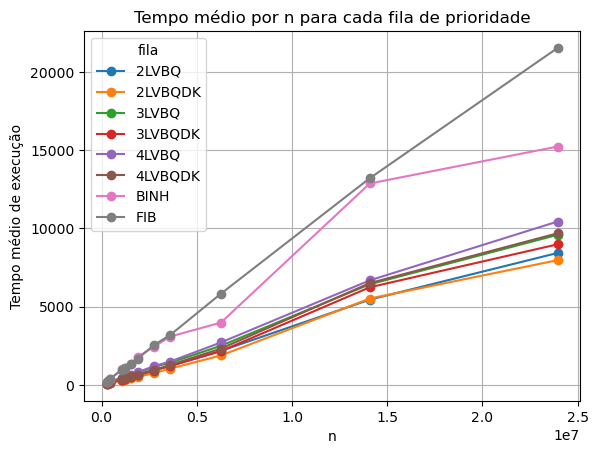

In [65]:
pivot = df.groupby(['n','fila'])['run'].mean().unstack()

pivot.plot(marker='o')
plt.xlabel('n')
plt.ylabel('Tempo médio de execução')
plt.title('Tempo médio por n para cada fila de prioridade')
plt.grid(True)
plt.savefig('run_n.png', dpi=300, bbox_inches='tight')
plt.show()


## Correlação entre métricas e tempo de execução

In [66]:
df['l1_mr'] = df['l1'] / df['cycles']
df['l2_mr'] = df['l2'] / df['cycles']
df['llc_mr'] = df['llc'] / df['cycles']

In [67]:
df_run_miss = (
    df.groupby(['nome','fila'])[['run','l1','l2','llc','cycles', 'inst', 'l1_mr', 'l2_mr', 'llc_mr']]
      .mean()
      .reset_index()
)

In [68]:
df_run_miss

,nome,fila,run,l1,l2,llc,cycles,inst,l1_mr,l2_mr,llc_mr
0,BAY,2LVBQ,104.4,3564908.1,1763884.2,153498.8,4.614121e+08,1.124805e+09,0.007726,0.003823,0.000333
1,BAY,2LVBQDK,78.7,3729676.9,1738882.1,165469.5,3.526732e+08,7.368221e+08,0.010576,0.004931,0.000469
2,BAY,3LVBQ,120.7,2638474.0,1566984.3,147924.0,5.324970e+08,1.357692e+09,0.004955,0.002943,0.000278
3,BAY,3LVBQDK,93.8,3513747.2,1757427.3,168897.6,4.194858e+08,9.102724e+08,0.008376,0.004190,0.000403
4,BAY,4LVBQ,127.5,2554898.0,1614201.8,155193.8,5.595401e+08,1.424972e+09,0.004566,0.002885,0.000277
...,...,...,...,...,...,...,...,...,...,...,...
91,W,3LVBQDK,2158.4,113516486.7,93116046.9,5476669.0,9.121307e+09,1.668947e+10,0.012445,0.010209,0.000600
92,W,4LVBQ,2715.8,71494479.2,68077004.7,4925557.5,1.125862e+10,2.580470e+10,0.006350,0.006047,0.000437
93,W,4LVBQDK,2322.1,118099577.3,93260031.3,5467756.2,9.796818e+09,1.852585e+10,0.012055,0.009519,0.000558
94,W,BINH,3983.7,70692748.8,64508731.1,5047062.8,1.636074e+10,4.067382e+10,0.004321,0.003943,0.000308
